# Кластеризация

В этом блокноте мы разберём основные алгоритмы **обучения без учителя** на примере задачи кластеризации. Мы познакомимся с:
- **метрическими пространствами** и различными мерами расстояния;
- алгоритмом **K-средних (K-Means)** и его сходимостью;
- **иерархической кластеризацией** и дендрограммами;
- **DBSCAN** — плотностным алгоритмом, устойчивым к выбросам;
- применением кластеризации для **поиска аномалий**;
- сравнением алгоритмов на реальных и синтетических данных.

> **Ключевая идея:** в задаче кластеризации у нас **нет меток** — мы не знаем правильного ответа заранее. Задача алгоритма — найти скрытую структуру в данных самостоятельно.

## Постановка задачи

Импортируем необходимые библиотеки:

In [ ]:
%matplotlib inline

In [63]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

sns.set_style("whitegrid")
np.random.seed(42)

Представим, что мы аналитики в сети розничных магазинов. У нас есть данные о покупателях: **частота посещений** (раз в месяц) и **средний чек** (тыс. руб.). Маркетинговая команда хочет разделить покупателей на группы, чтобы предложить каждой группе подходящие акции.

Сгенерируем синтетические данные, имитирующие три типичных сегмента: редкие покупки на большую сумму, частые покупки на малую сумму, средний сегмент. 

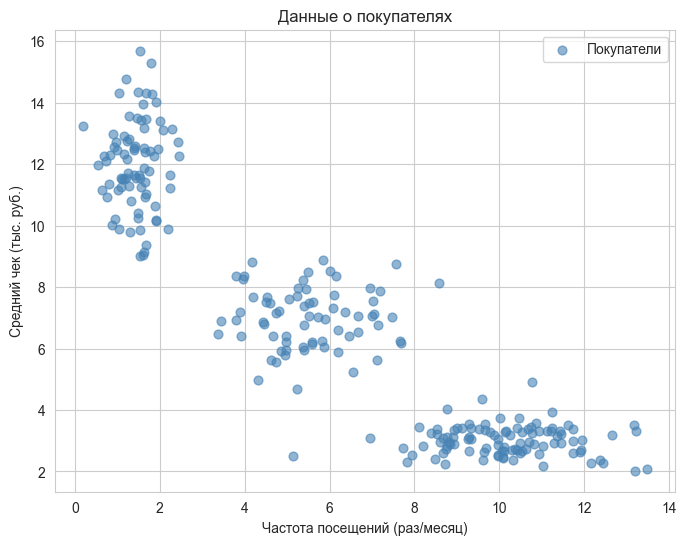

In [44]:
np.random.seed(42)

seg1 = np.random.randn(80, 2) * [0.5, 1.5] + [1.5, 12]   # редко, дорого
seg2 = np.random.randn(100, 2) * [1.5, 0.5] + [10, 3]    # часто, дёшево
seg3 = np.random.randn(70, 2) * [1.0, 1.0] + [5.5, 7]    # средний сегмент

X = np.vstack([seg1, seg2, seg3])
outliers = np.array([[15, 15], [0.5, 0.5], [14, 1], [2, 16]])
X = np.vstack([X, outliers])

plt.figure(figsize=(8, 6))
plt.scatter(X[:-4, 0], X[:-4, 1], alpha=0.6, s=40, color='steelblue', label='Покупатели')
plt.xlabel('Частота посещений (раз/месяц)')
plt.ylabel('Средний чек (тыс. руб.)')
plt.title('Данные о покупателях')
plt.legend()
plt.show()

### k-means по шагам

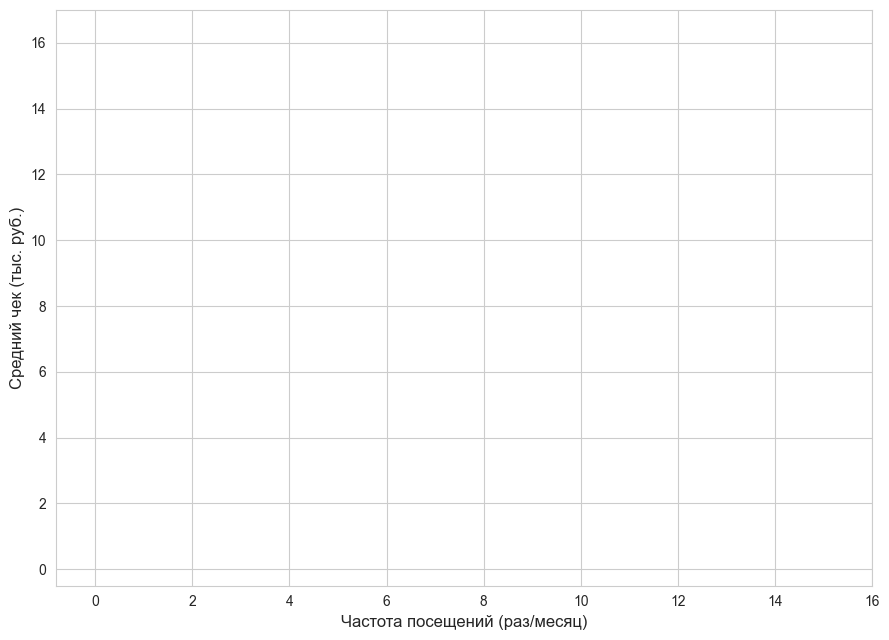

Шагов до сходимости: 7


In [45]:
import matplotlib.animation as animation

# --- K-means вручную: сохраняем все шаги ---
def run_kmeans_steps(X, k=3, max_iter=15, seed=7):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), k, replace=False)
    centroids = X[idx].copy()
    steps = []
    for iteration in range(max_iter):
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)
        labels = np.argmin(dists, axis=1)
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
            for j in range(k)
        ])
        steps.append({
            'centroids_old': centroids.copy(),
            'centroids_new': new_centroids.copy(),
            'labels': labels.copy(),
            'iteration': iteration + 1,
        })
        if np.allclose(centroids, new_centroids, atol=1e-6):
            break
        centroids = new_centroids.copy()
    return steps

steps = run_kmeans_steps(X, k=3)

# --- Анимация ---
COLORS = ['#E63946', '#2A9D8F', '#E9C46A']
CENTROID_EDGE = '#264653'
FRAMES_PER_STEP = 8
total_frames = len(steps) * (1 + FRAMES_PER_STEP)

fig_anim, ax_anim = plt.subplots(figsize=(9, 6.5))
ax_anim.set_xlabel('Частота посещений (раз/месяц)', fontsize=12)
ax_anim.set_ylabel('Средний чек (тыс. руб.)', fontsize=12)
ax_anim.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax_anim.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)

def draw_frame(frame):
    ax_anim.cla()
    ax_anim.set_xlabel('Частота посещений (раз/месяц)', fontsize=12)
    ax_anim.set_ylabel('Средний чек (тыс. руб.)', fontsize=12)
    ax_anim.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    ax_anim.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    ax_anim.grid(True, alpha=0.3)

    step_idx = frame // (1 + FRAMES_PER_STEP)
    sub = frame % (1 + FRAMES_PER_STEP)
    step = steps[step_idx]
    labels = step['labels']
    c_old = step['centroids_old']
    c_new = step['centroids_new']

    if sub == 0:
        for j in range(3):
            mask = labels == j
            ax_anim.scatter(X[mask, 0], X[mask, 1],
                            color=COLORS[j], alpha=0.65, s=40, label=f'Кластер {j+1}')
        centroids_show = c_old
        title = f'Итерация {step["iteration"]}: назначение точек кластерам'
    else:
        t = sub / FRAMES_PER_STEP
        for j in range(3):
            mask = labels == j
            ax_anim.scatter(X[mask, 0], X[mask, 1],
                            color=COLORS[j], alpha=0.65, s=40, label=f'Кластер {j+1}')
        centroids_show = c_old + t * (c_new - c_old)
        title = (f'Итерация {step["iteration"]}: центроиды обновлены'
                 if sub == FRAMES_PER_STEP
                 else f'Итерация {step["iteration"]}: перемещение центроидов...')

    for j in range(3):
        ax_anim.scatter(*centroids_show[j], color=COLORS[j],
                        s=280, marker='*', edgecolors=CENTROID_EDGE,
                        linewidths=1.5, zorder=5)
        if 0 < sub < FRAMES_PER_STEP:
            ax_anim.annotate('', xy=c_new[j], xytext=c_old[j],
                             arrowprops=dict(arrowstyle='->', color=CENTROID_EDGE,
                                             lw=1.5, alpha=0.5))

    ax_anim.set_title(title, fontsize=13, fontweight='bold')
    ax_anim.legend(loc='upper right', fontsize=10)

ani = animation.FuncAnimation(
    fig_anim, draw_frame,
    frames=total_frames,
    interval=120,
    repeat=True,
    repeat_delay=2000,
)

plt.tight_layout()
plt.show()

ani.save('kmeans.gif', writer='pillow', fps=10)
print(f'Шагов до сходимости: {len(steps)}')

**Вопросы:**
- Как формально измерить, насколько две точки похожи друг на друга?
- Что будет, если признаки имеют очень разные масштабы (например, частота — от 1 до 15, а сумма — от 1 000 до 100 000 рублей)?

### Ответ

На графике видны три относительно обособленных облака точек. Для формального измерения схожести объектов используют **функцию расстояния** в метрическом пространстве.

Функция $d: X \times X \to \mathbb{R}$ называется **метрикой**, если для любых $x, y, z \in X$:
1. $d(x, y) \geq 0$, и $d(x, y) = 0 \Leftrightarrow x = y$ (невырожденность)
2. $d(x, y) = d(y, x)$ (симметрия)
3. $d(x, z) \leq d(x, y) + d(y, z)$ (неравенство треугольника)

Наиболее часто используемые метрики:

| Метрика | Формула | Когда использовать |
|---|---|---|
| Евклидова | $d_E(x,y) = \sqrt{\sum_i (x_i - y_i)^2}$ | Числовые признаки, шаровые кластеры |
| Манхэттенская | $d_M(x,y) = \sum_i \vert x_i - y_i \vert$ | Устойчивее к выбросам |
| Чебышёва | $d_C(x,y) = \max_i \vert x_i - y_i \vert$ | Когда важен максимум отклонений |
| Косинусная | $1 - \cos(x, y)$ | Текстовые данные |


**Важно:** поскольку расстояния вычисляются покоординатно, признаки с большим масштабом будут **доминировать** в сумме. Поэтому перед кластеризацией данные, как правило, **стандартизируют**: $z = (x - \mu) / \sigma$.

#### Комментарий
$$z = \dfrac{x - \mu}{\sigma}$$

$\mu$ — это просто среднее всех значений признака.

Например, средняя частота посещений по всем покупателям = 6 раз/месяц. Это и есть $\mu$.

$\sigma$ — это стандартное отклонение, то есть насколько значения в среднем разбросаны вокруг среднего.

Если большинство ходит 4–8 раз — разброс маленький, $\sigma ≈ 2$. Если кто-то ходит 1 раз, кто-то 15 — разброс большой, $\sigma ≈ 5$.

### Метрические пространства: влияние масштабирования

Напишите код:
1. Стандартизируйте данные `X` с помощью `StandardScaler`.
2. Вычислите попарные евклидовы расстояния между первыми **10 объектами** до и после стандартизации (используйте `cdist` из `scipy.spatial.distance`).
3. Визуализируйте обе матрицы расстояний с помощью `sns.heatmap` рядом.
4. Прокомментируйте: как изменились расстояния и почему это важно?

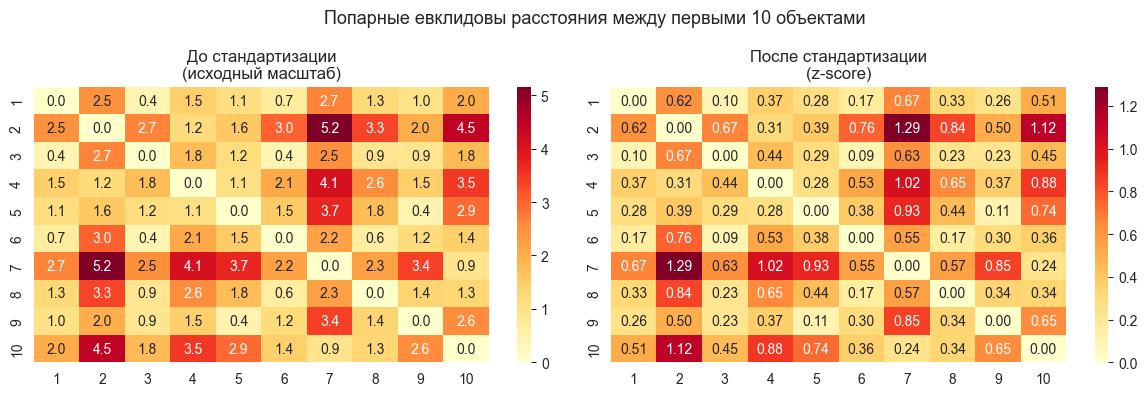

До стандартизации — мин: 0.37,  макс: 5.16
После стандартизации — мин: 0.09, макс: 1.29


In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

D_raw    = cdist(X[:10],        X[:10])
D_scaled = cdist(X_scaled[:10], X_scaled[:10])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(D_raw,    ax=axes[0], annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=range(1,11), yticklabels=range(1,11))
axes[0].set_title('До стандартизации\n(исходный масштаб)', fontsize=12)

sns.heatmap(D_scaled, ax=axes[1], annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=range(1,11), yticklabels=range(1,11))
axes[1].set_title('После стандартизации\n(z-score)', fontsize=12)

plt.suptitle('Попарные евклидовы расстояния между первыми 10 объектами', fontsize=13)
plt.tight_layout()
plt.show()

print(f"До стандартизации — мин: {D_raw[D_raw>0].min():.2f},  макс: {D_raw.max():.2f}")
print(f"После стандартизации — мин: {D_scaled[D_scaled>0].min():.2f}, макс: {D_scaled.max():.2f}")

## Алгоритм K-средних (K-Means)

### Идея и математика

Метод K-средних разбивает $n$ объектов на $K$ непересекающихся кластеров $C_1, \ldots, C_K$, минимизируя **суммарную внутрикластерную дисперсию (инерцию)**:

$$
J = \sum_{k=1}^{K} \sum_{x \in C_k} \|x - \bar{x}_k\|^2 \to \min,
$$

где $\bar{x}_k = \dfrac{1}{|C_k|} \sum_{x \in C_k} x$ — **центроид** (центр масс) кластера $C_k$.

**Алгоритм:**
1. Выбрать число кластеров $K$.
2. Инициализировать $K$ центроидов (случайно или методом K-Means++).
3. **Шаг назначения:** отнести каждый объект к кластеру с ближайшим центроидом:
$$c_i = \underset{k}{\arg\min}\ \|x_i - \bar{x}_k\|^2$$
4. **Шаг обновления:** пересчитать центроиды как центры масс новых кластеров.
5. Повторять 3–4 до сходимости.


### Шаг за шагом: визуализация итераций K-Means

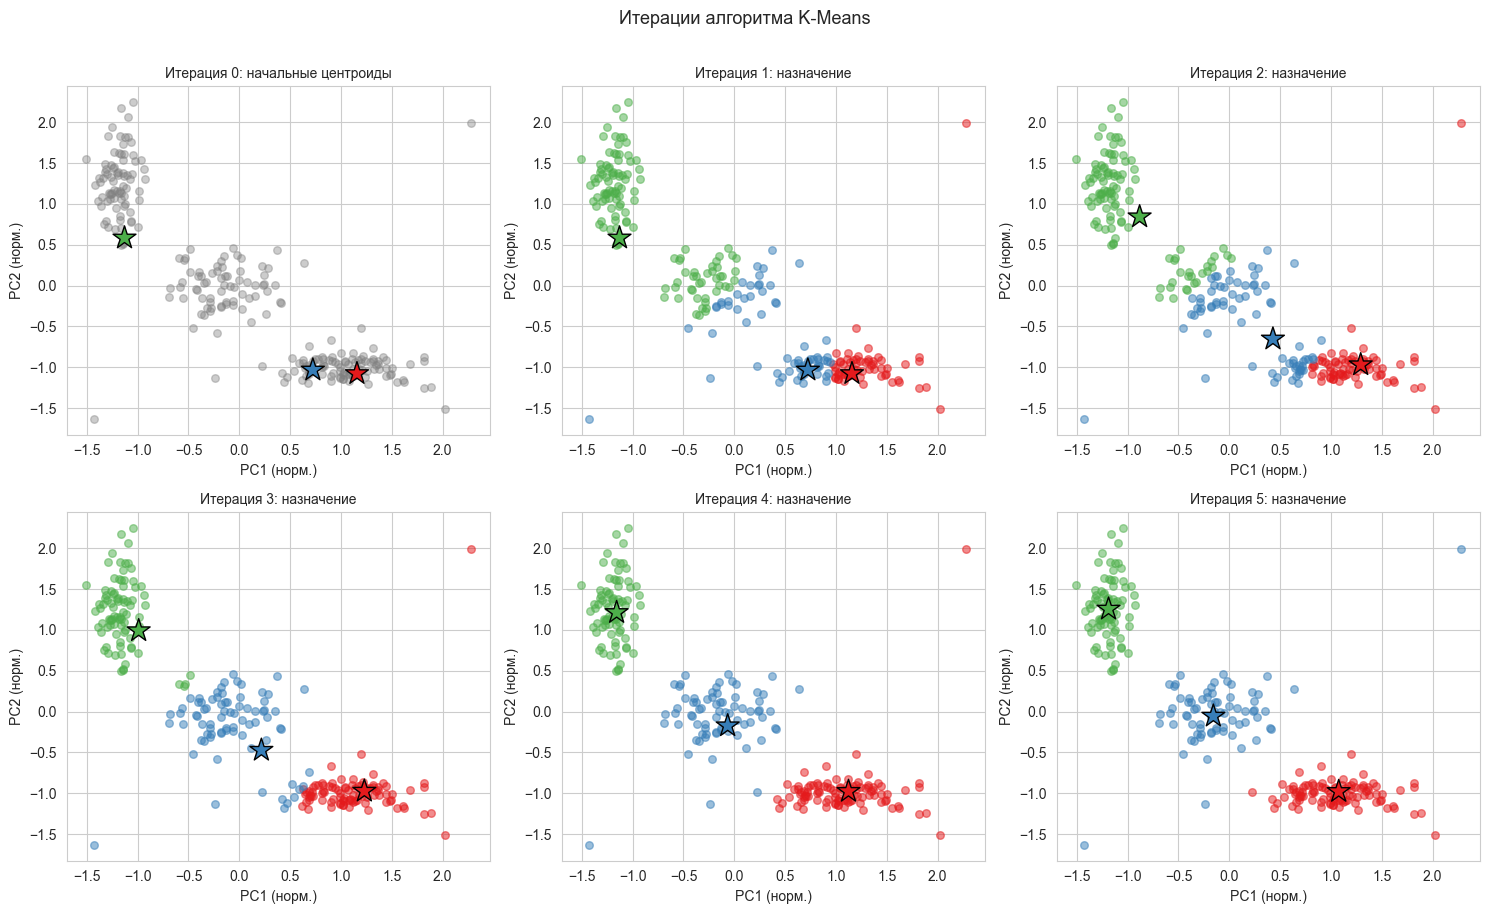

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def plot_kmeans_step(X, centroids, labels=None, title='', ax=None):
    if ax is None:
        ax = plt.gca()
    colors = ['#e41a1c', '#377eb8', '#4daf4a']
    if labels is not None:
        for k in range(len(centroids)):
            mask = labels == k
            ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.5, s=30)
    else:
        ax.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.4, s=30)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c=colors[:len(centroids)], marker='*', s=300,
               edgecolors='black', linewidths=1, zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1 (норм.)')
    ax.set_ylabel('PC2 (норм.)')

K = 3
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

np.random.seed(7)
idx = np.random.choice(len(X_scaled), K, replace=False)
centroids = X_scaled[idx].copy()
plot_kmeans_step(X_scaled, centroids, title='Итерация 0: начальные центроиды', ax=axes[0, 0])

for step in range(5):
    dists = cdist(X_scaled, centroids)
    labels_iter = np.argmin(dists, axis=1)
    ax = axes[(step + 1) // 3][(step + 1) % 3]
    plot_kmeans_step(X_scaled, centroids, labels_iter,
                     title=f'Итерация {step + 1}: назначение', ax=ax)
    centroids = np.array([X_scaled[labels_iter == k].mean(axis=0) for k in range(K)])

plt.suptitle('Итерации алгоритма K-Means', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### K-Means в scikit-learn

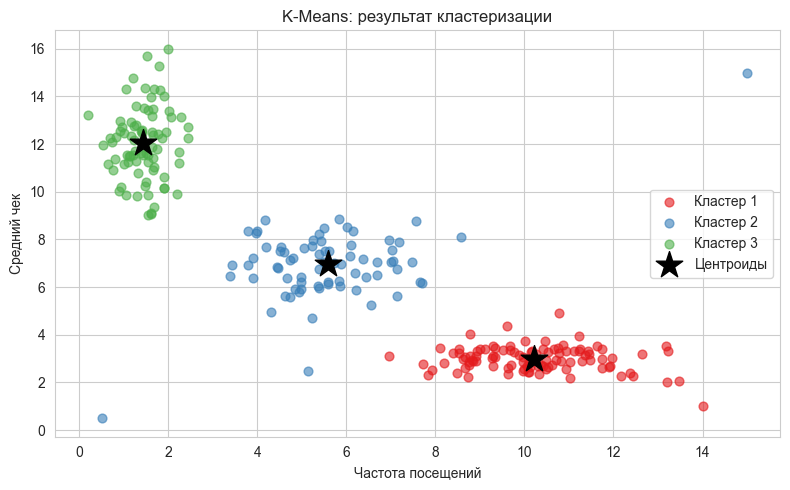

Центроиды в исходном масштабе:
Кластер      Частота (раз/мес)    Ср. чек (тыс.руб.)     Размер
Кластер 1    10.22              3.00              100
Кластер 2    5.59              6.97              73
Кластер 3    1.44              12.04              81


In [56]:
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e41a1c', '#377eb8', '#4daf4a']
for k in range(3):
    mask = labels_km == k
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.6, s=40, label=f'Кластер {k+1}')
ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           c='black', marker='*', s=400, zorder=5, label='Центроиды')
ax.set_xlabel('Частота посещений')
ax.set_ylabel('Средний чек')
ax.set_title('K-Means: результат кластеризации')
ax.legend()

plt.tight_layout()
plt.show()

print("Центроиды в исходном масштабе:")
print(f"{'Кластер':<12} {'Частота (раз/мес)':<20} {'Ср. чек (тыс.руб.)':<22} {'Размер'}")
for k in range(3):
    n_k = np.sum(labels_km == k)
    print(f"Кластер {k+1}    {centroids_orig[k, 0]:.2f}{'':>14}{centroids_orig[k, 1]:.2f}{'':>14}{n_k}")

### Выбор числа кластеров: метод локтя и силуэтный коэффициент

Два основных подхода к выбору $K$:

**1. Метод локтя (Elbow method):** строим инерцию как функцию $K$ и ищем «перегиб» — точку, после которой убывание замедляется.

**2. Силуэтный коэффициент:** для каждого объекта $x_i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}, \quad s(i) \in [-1, 1],$$
где $a(i)$ — среднее расстояние до объектов **своего** кластера, $b(i)$ — среднее расстояние до объектов **ближайшего чужого** кластера.
Чем ближе $s(i)$ к $1$ — тем лучше. Мы максимизируем **средний** силуэт по всем объектам.

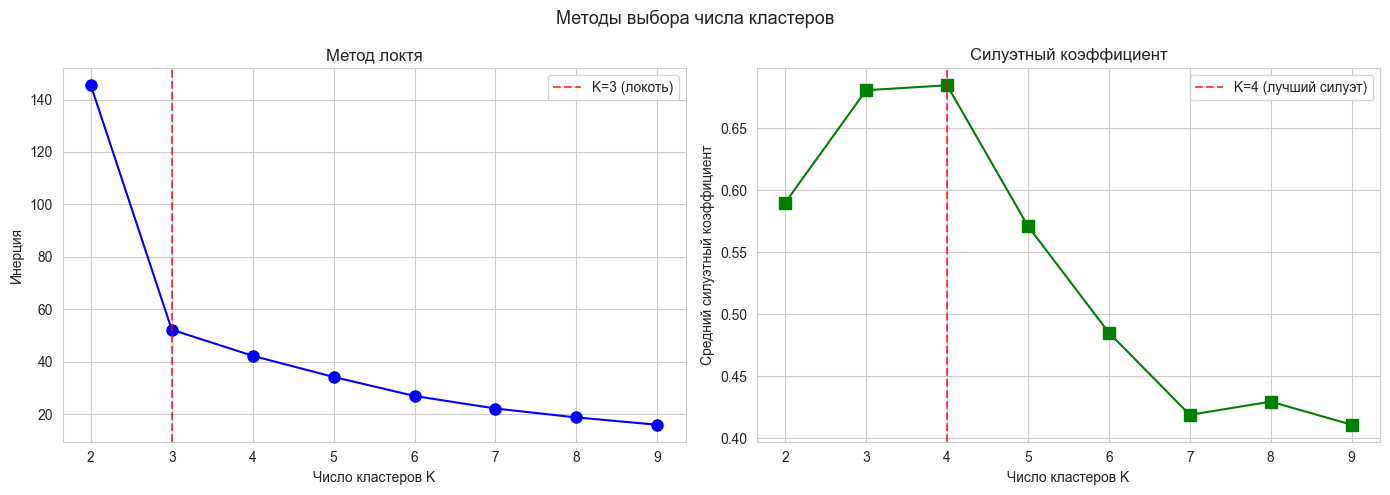

Оптимальное K по силуэту: 4


In [64]:
K_range = range(2, 10)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (локоть)')
axes[0].set_xlabel('Число кластеров K')
axes[0].set_ylabel('Инерция')
axes[0].set_title('Метод локтя')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'gs-', markersize=8)
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'K={best_k} (лучший силуэт)')
axes[1].set_xlabel('Число кластеров K')
axes[1].set_ylabel('Средний силуэтный коэффициент')
axes[1].set_title('Силуэтный коэффициент')
axes[1].legend()

plt.suptitle('Методы выбора числа кластеров', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Оптимальное K по силуэту: {best_k}")

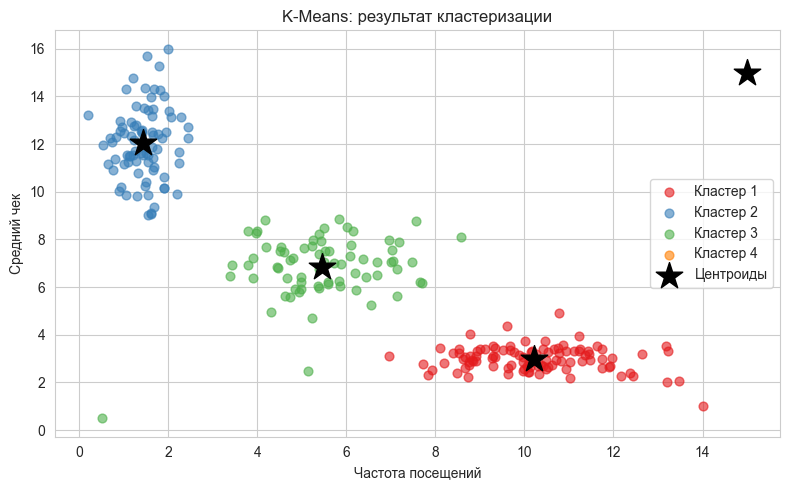

Центроиды в исходном масштабе:
Кластер      Частота (раз/мес)    Ср. чек (тыс.руб.)     Размер
Кластер 1    10.22              3.00              100
Кластер 2    1.44              12.04              81
Кластер 3    5.46              6.86              72
Кластер 4    15.00              15.00              1


In [66]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

for k in range(4):
    mask = labels_km == k
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.6, s=40, label=f'Кластер {k+1}')

ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           c='black', marker='*', s=400, zorder=5, label='Центроиды')
ax.set_xlabel('Частота посещений')
ax.set_ylabel('Средний чек')
ax.set_title('K-Means: результат кластеризации')
ax.legend()
plt.tight_layout()
plt.show()

print("Центроиды в исходном масштабе:")
print(f"{'Кластер':<12} {'Частота (раз/мес)':<20} {'Ср. чек (тыс.руб.)':<22} {'Размер'}")
for k in range(4):
    n_k = np.sum(labels_km == k)
    print(f"Кластер {k+1}    {centroids_orig[k, 0]:.2f}{'':>14}{centroids_orig[k, 1]:.2f}{'':>14}{n_k}")

**Вопросы:**
- Что произойдёт с результатом K-Means, если запустить алгоритм несколько раз с разными начальными центроидами? Почему?
- Что означает отрицательный силуэтный коэффициент для отдельного объекта?
- Для каких форм кластеров K-Means работает плохо?

### Ответ

**Нестабильность:** K-Means гарантирует сходимость лишь к **локальному** минимуму инерции $J$. Разные начальные центроиды ведут к разным финальным разбиениям. Именно поэтому алгоритм запускают несколько раз (`n_init`) и выбирают наилучший результат. Метод K-Means++ снижает эту проблему, рассредотачивая начальные центроиды по пространству — вероятность выбора $i$-й точки в качестве следующего центроида пропорциональна $d_i$ (расстоянию до ближайшего уже выбранного центроида).

**Отрицательный силуэт** означает, что объект в среднем ближе к точкам **чужого** кластера, чем к своему. Алгоритм, вероятно, ошибся с назначением — объект находится на границе кластеров.

**Ограничения K-Means:** алгоритм предполагает **шаровые кластеры** примерно одинакового размера. Он плохо работает при ленточных, кольцеобразных или сильно различающихся по размеру кластерах, а также при наличии выбросов (они «притягивают» центроид к себе).

### K-Means на нелинейных данных

Используя LLM для генерации кода:
1. Сгенерируйте `make_moons(n_samples=300, noise=0.1)` и `make_circles(n_samples=300, noise=0.05, factor=0.5)`.
2. Примените K-Means с `n_clusters=2` к каждому датасету (со стандартизацией).
3. Постройте 4 графика: истинные кластеры и результат K-Means для каждого датасета.
4. Вычислите силуэтный коэффициент. Объясните результаты.

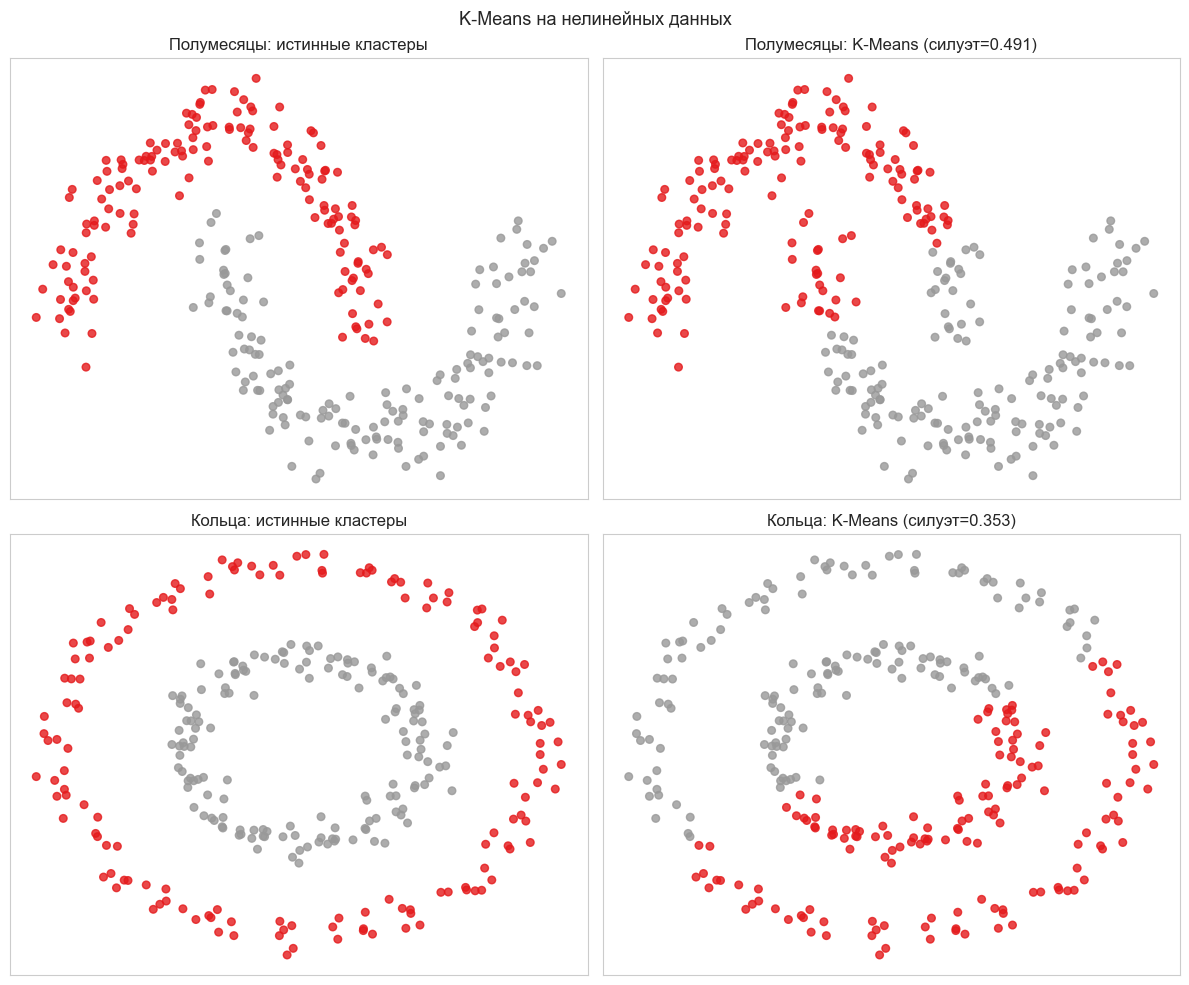

In [73]:
# Генерация данных
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Стандартизация
X_moons_s = StandardScaler().fit_transform(X_moons)
X_circles_s = StandardScaler().fit_transform(X_circles)

# K-Means
km_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
km_circles = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_moons = km_moons.fit_predict(X_moons_s)
labels_circles = km_circles.fit_predict(X_circles_s)

sil_moons = silhouette_score(X_moons_s, labels_moons)
sil_circles = silhouette_score(X_circles_s, labels_circles)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='Set1', s=30, alpha=0.8)
axes[0, 0].set_title('Полумесяцы: истинные кластеры')

axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons, cmap='Set1', s=30, alpha=0.8)
axes[0, 1].set_title(f'Полумесяцы: K-Means (силуэт={sil_moons:.3f})')

axes[1, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='Set1', s=30, alpha=0.8)
axes[1, 0].set_title('Кольца: истинные кластеры')

axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_circles, cmap='Set1', s=30, alpha=0.8)
axes[1, 1].set_title(f'Кольца: K-Means (силуэт={sil_circles:.3f})')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('K-Means на нелинейных данных', fontsize=13)
plt.tight_layout()

## Иерархическая кластеризация

### Идея и алгоритм

Иерархическая кластеризация строит **дерево кластеров (дендрограмму)**, не требуя задавать $K$ заранее. Наиболее популярен **агломеративный** (снизу вверх) подход:
1. Начать с $n$ кластеров — каждый объект в отдельном кластере.
2. На каждом шаге объединять два ближайших кластера.
3. Повторять до тех пор, пока не останется один кластер.

Ключевой вопрос — **как измерять расстояние между кластерами** (linkage):

| Метод | Формула | Особенность |
|---|---|---|
| Одиночная связь (single) | $\min_{x \in C_i, y \in C_j} d(x,y)$ | Склонна к «цепочкам» |
| Полная связь (complete) | $\max_{x \in C_i, y \in C_j} d(x,y)$ | Компактные кластеры |
| Средняя связь (average) | $\frac{1}{ \vert C_i \vert \vert C_j \vert }\sum d(x,y)$ | Компромисс |
| Метод Уорда (ward) | $\Delta J$ при объединении | Минимизирует дисперсию |

**Дендрограмма** визуализирует иерархию: ось $Y$ — расстояние при объединении, горизонтальный срез на уровне $\rho$ соответствует конкретному числу кластеров.

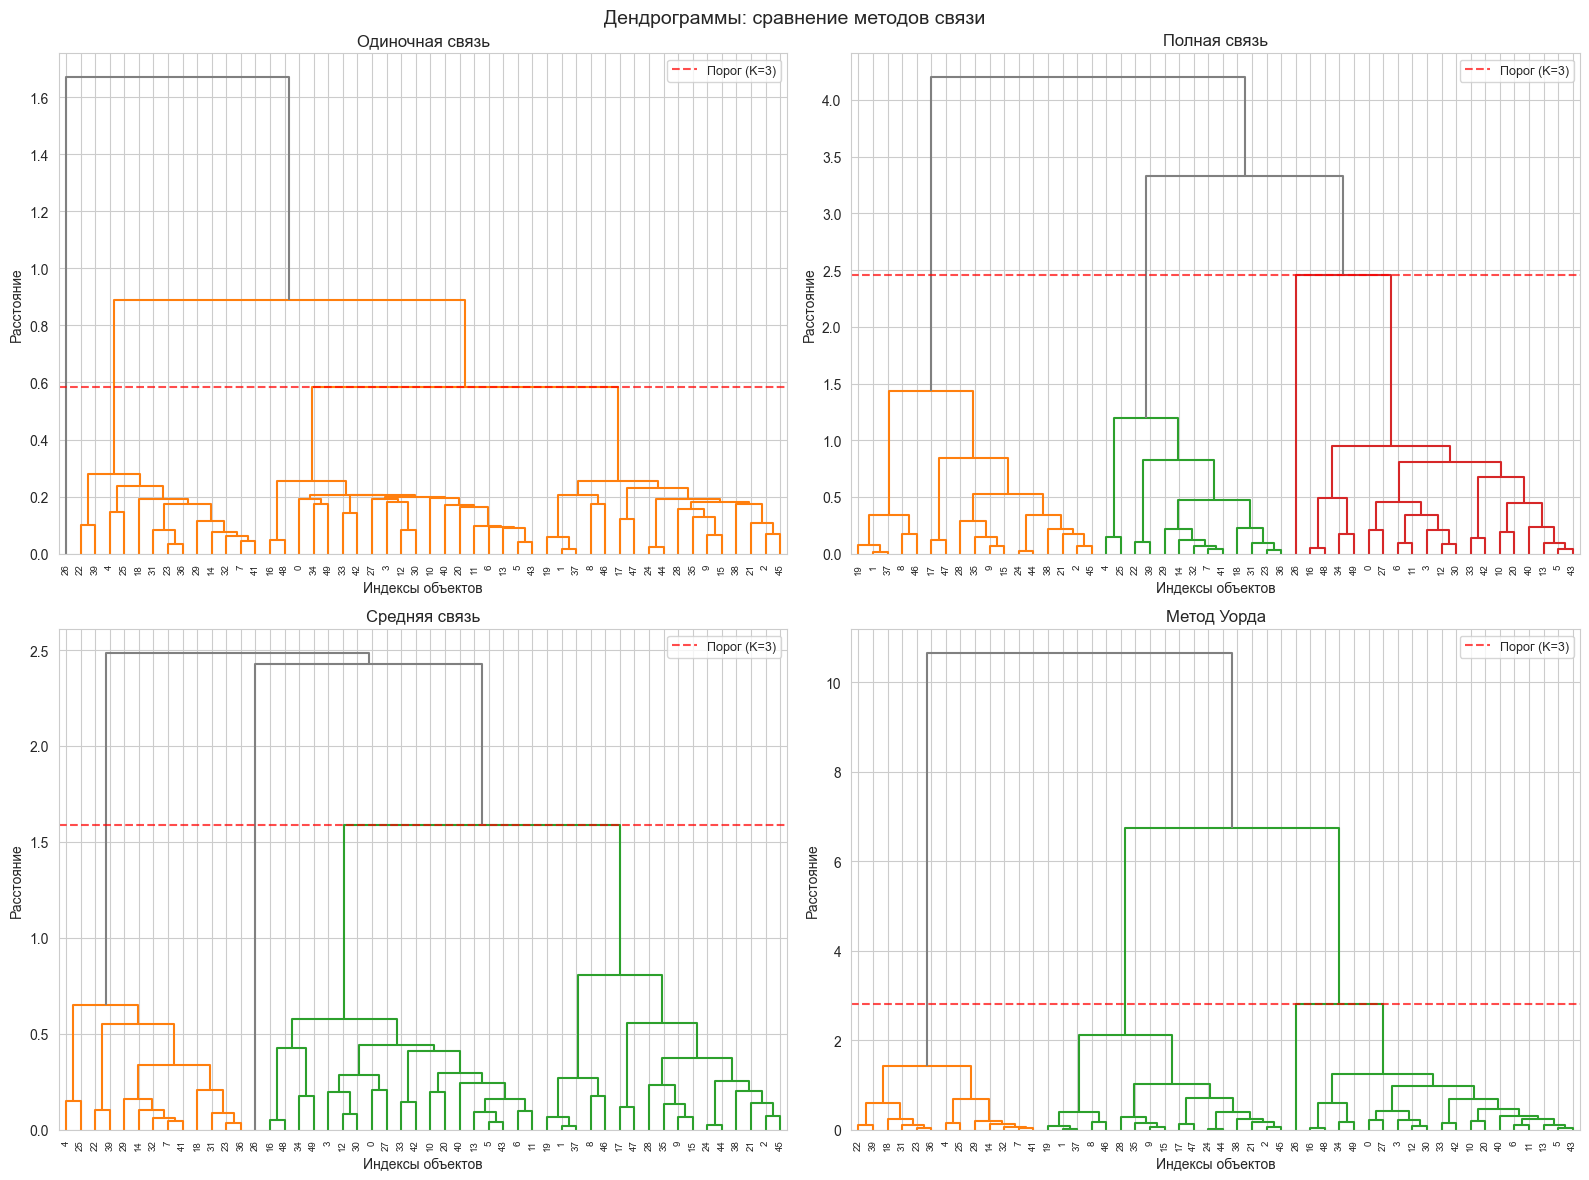

In [85]:
np.random.seed(42)
sample_idx = np.random.choice(len(X), 50, replace=False)
X_sample = X_scaled[sample_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
linkage_methods = ['single', 'complete', 'average', 'ward']
method_names = ['Одиночная связь', 'Полная связь', 'Средняя связь', 'Метод Уорда']

for ax, method, name in zip(axes.flat, linkage_methods, method_names):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=7,
               color_threshold=0.7 * max(Z[:, 2]), above_threshold_color='gray')
    threshold = sorted(Z[:, 2], reverse=True)[2]
    ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, label='Порог (K=3)')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Индексы объектов')
    ax.set_ylabel('Расстояние')
    ax.legend(fontsize=9)

plt.suptitle('Дендрограммы: сравнение методов связи', fontsize=14)
plt.tight_layout()
plt.show()

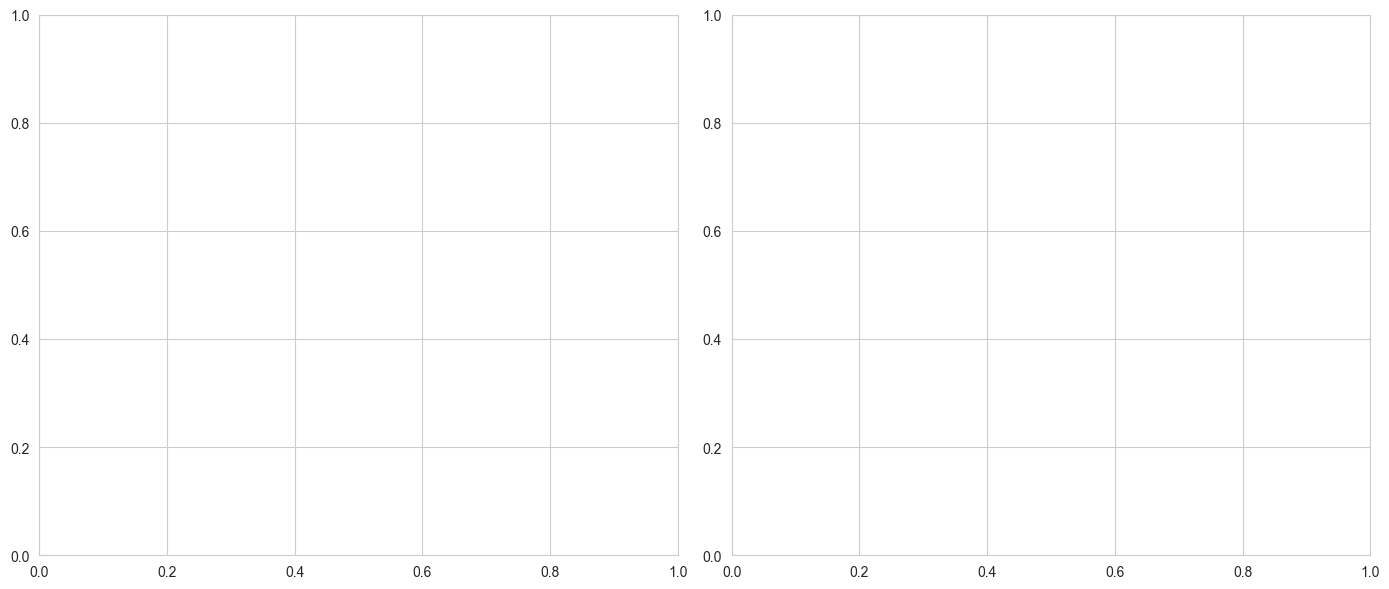

Всего кадров: 124, шагов слияния: 7


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform

# --- Данные: 8 точек с явной структурой ---
np.random.seed(42)
X_hier = np.array([
    [1.0, 2.0], [1.5, 1.5], [1.2, 2.5],   # группа A (левый нижний)
    [5.0, 5.5], [5.5, 5.0], [4.8, 5.8],   # группа B (правый верхний)
    [8.0, 2.0], [8.5, 2.5],               # группа C (правый нижний)
])
LABELS = ['A1','A2','A3','B1','B2','B3','C1','C2']
n = len(X_hier)

# --- Вычисляем шаги слияния через scipy ---
Z = linkage(X_hier, method='ward')
# Z[i] = [idx1, idx2, distance, count]

# --- Восстанавливаем историю кластеров шаг за шагом ---
def build_merge_steps(X, Z):
    """Возвращает список шагов: на каждом шаге — текущие кластеры и что сливается."""
    n = len(X)
    # cluster_id -> список индексов точек
    clusters = {i: [i] for i in range(n)}
    next_id = n
    steps = []

    # Начальное состояние
    steps.append({
        'clusters': {k: list(v) for k, v in clusters.items()},
        'merging': None,
        'new_id': None,
        'distance': 0,
        'iteration': 0,
    })

    for row in Z:
        id1, id2, dist, _ = int(row[0]), int(row[1]), row[2], int(row[3])
        merged = clusters[id1] + clusters[id2]
        steps.append({
            'clusters': {k: list(v) for k, v in clusters.items()},
            'merging': (id1, id2),
            'new_id': next_id,
            'distance': dist,
            'iteration': len(steps),
        })
        del clusters[id1]
        del clusters[id2]
        clusters[next_id] = merged
        next_id += 1

    # Финальное состояние
    steps.append({
        'clusters': {k: list(v) for k, v in clusters.items()},
        'merging': None,
        'new_id': None,
        'distance': 0,
        'iteration': len(steps),
    })
    return steps

steps_hier = build_merge_steps(X_hier, Z)

# --- Цвета для кластеров ---
BASE_COLORS = [
    '#E63946', '#2A9D8F', '#E9C46A', '#6A4C93',
    '#F4A261', '#457B9D', '#2D6A4F', '#E76F51', '#A8DADC',
]

def get_cluster_colors(clusters):
    """Назначаем каждому кластеру цвет по его минимальному исходному индексу."""
    color_map = {}  # point_idx -> color
    for i, (cid, members) in enumerate(sorted(clusters.items(), key=lambda x: min(x[1]))):
        color = BASE_COLORS[i % len(BASE_COLORS)]
        for m in members:
            color_map[m] = color
    return color_map

def cluster_centroid(members, X):
    return X[members].mean(axis=0)

def draw_ellipse(ax, members, X, color, alpha=0.15, lw=2):
    """Рисует эллипс вокруг группы точек."""
    if len(members) == 1:
        ax.add_patch(plt.Circle(X[members[0]], 0.35,
                                color=color, alpha=alpha + 0.1, zorder=1))
        ax.add_patch(plt.Circle(X[members[0]], 0.35,
                                fill=False, edgecolor=color, lw=lw, zorder=2))
        return
    pts = X[members]
    cx, cy = pts.mean(axis=0)
    rx = max(pts[:, 0].std() * 1.8, 0.5)
    ry = max(pts[:, 1].std() * 1.8, 0.5)
    ellipse = mpatches.Ellipse((cx, cy), width=rx * 2.5, height=ry * 2.5,
                               color=color, alpha=alpha, zorder=1)
    ax.add_patch(ellipse)
    ellipse_border = mpatches.Ellipse((cx, cy), width=rx * 2.5, height=ry * 2.5,
                                     fill=False, edgecolor=color, lw=lw, zorder=2)
    ax.add_patch(ellipse_border)

# --- Строим дендрограмму вручную (шаг за шагом) ---
def compute_dendrogram_coords(Z, n):
    """
    Возвращает координаты для рисования дендрограммы.
    leaf_x: x-позиция каждой исходной точки
    node_coords: {cluster_id: (x, y)} — координаты каждого узла
    merge_lines: список ((x1,x2,xm,xm), (y_base1, y_base2, y_base, y_base))
                 для рисования перевёрнутой U на каждом слиянии
    """
    # Расставляем листья по x
    leaf_x = {i: float(i) for i in range(n)}
    node_coords = {i: (float(i), 0.0) for i in range(n)}
    merge_lines = []   # список {'ids': (id1,id2), 'lines': [...], 'height': dist}
    next_id = n

    for row in Z:
        id1, id2, dist = int(row[0]), int(row[1]), row[2]
        x1, y1 = node_coords[id1]
        x2, y2 = node_coords[id2]
        xm = (x1 + x2) / 2
        # линии: вертикаль от y1 до dist, горизонталь x1-x2, вертикаль от y2 до dist
        merge_lines.append({
            'ids': (id1, id2),
            'x_left': x1, 'x_right': x2, 'x_mid': xm,
            'y_left': y1, 'y_right': y2, 'y_top': dist,
        })
        node_coords[next_id] = (xm, dist)
        next_id += 1

    return leaf_x, node_coords, merge_lines

leaf_x, node_coords, merge_lines = compute_dendrogram_coords(Z, n)
max_dist = Z[:, 2].max()

# --- Анимация ---
PAUSE_FRAMES = 6     # пауза на показ «до слияния»
MOVE_FRAMES  = 10    # анимация самого слияния

# Формируем кадры: для каждого шага (кроме начального) — пауза + движение
frame_plan = []  # (step_idx, sub_frame)
frame_plan += [(0, 0)] * PAUSE_FRAMES  # начальное состояние

for s in range(1, len(steps_hier) - 1):   # шаги слияния
    for sub in range(PAUSE_FRAMES):        # пауза перед слиянием
        frame_plan.append((s, sub))
    for sub in range(MOVE_FRAMES):         # анимация слияния
        frame_plan.append((s, PAUSE_FRAMES + sub))

frame_plan += [(len(steps_hier) - 1, 0)] * PAUSE_FRAMES  # финал

fig_hier, (ax_scatter, ax_dendro) = plt.subplots(1, 2, figsize=(14, 6))

def draw_frame_hier(frame):
    step_idx, sub = frame_plan[frame]
    step = steps_hier[step_idx]
    t = max(0.0, (sub - PAUSE_FRAMES) / MOVE_FRAMES) if sub >= PAUSE_FRAMES else 0.0

    # ── Левая панель: точки ──────────────────────────────────────────
    ax_scatter.cla()
    ax_scatter.set_xlim(X_hier[:, 0].min() - 1, X_hier[:, 0].max() + 1)
    ax_scatter.set_ylim(X_hier[:, 1].min() - 1, X_hier[:, 1].max() + 1)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_title('Шаги агломеративной кластеризации', fontsize=12, fontweight='bold')
    ax_scatter.set_xlabel('Признак 1', fontsize=11)
    ax_scatter.set_ylabel('Признак 2', fontsize=11)

    clusters = step['clusters']
    color_map = get_cluster_colors(clusters)

    # Рисуем эллипсы вокруг кластеров
    for cid, members in clusters.items():
        color = color_map[members[0]]
        # При слиянии — подсвечиваем сливаемую пару
        merging = step.get('merging')
        if merging and cid in merging:
            draw_ellipse(ax_scatter, members, X_hier, color, alpha=0.25 + 0.2 * t, lw=2.5)
        else:
            draw_ellipse(ax_scatter, members, X_hier, color, alpha=0.15, lw=1.5)

    # Рисуем точки
    for i in range(n):
        ax_scatter.scatter(*X_hier[i], color=color_map[i], s=120,
                           edgecolors='#264653', linewidths=1.2, zorder=5)
        ax_scatter.annotate(LABELS[i], X_hier[i], textcoords='offset points',
                            xytext=(6, 4), fontsize=9, color='#264653')

    # Подпись итерации
    iteration = step['iteration']
    if step['merging']:
        id1, id2 = step['merging']
        m1 = clusters[id1]
        m2 = clusters[id2]
        n_clusters = len(clusters)
        dist = step['distance']
        ax_scatter.set_xlabel(
            f'Итерация {iteration}: объединяем {[LABELS[i] for i in m1]} '
            f'и {[LABELS[i] for i in m2]}  |  '
            f'расстояние = {dist:.2f}  |  кластеров: {n_clusters}',
            fontsize=9
        )
    elif iteration == 0:
        ax_scatter.set_xlabel(f'Начало: {n} кластеров — каждая точка сама по себе', fontsize=10)
    else:
        ax_scatter.set_xlabel('Готово: все точки в одном кластере', fontsize=10)

    # ── Правая панель: дендрограмма (строится постепенно) ────────────
    ax_dendro.cla()
    ax_dendro.set_xlim(-0.7, n - 0.3)
    ax_dendro.set_ylim(-max_dist * 0.08, max_dist * 1.15)
    ax_dendro.set_title('Дендрограмма', fontsize=12, fontweight='bold')
    ax_dendro.set_ylabel('Расстояние при объединении', fontsize=10)
    ax_dendro.set_xticks(range(n))
    ax_dendro.set_xticklabels(LABELS, fontsize=9)
    ax_dendro.grid(True, axis='y', alpha=0.3)
    ax_dendro.axhline(0, color='gray', lw=0.5)

    # Рисуем только те слияния, что уже произошли
    merges_done = step['iteration'] - (1 if step['merging'] else 0)
    current_merge_idx = step['iteration'] - 1  # индекс текущего слияния в Z

    for mi, ml in enumerate(merge_lines):
        if mi < merges_done:
            # Уже выполненные слияния
            color_line = BASE_COLORS[mi % len(BASE_COLORS)]
            ax_dendro.plot([ml['x_left'], ml['x_left']],
                          [ml['y_left'], ml['y_top']], color=color_line, lw=2)
            ax_dendro.plot([ml['x_right'], ml['x_right']],
                          [ml['y_right'], ml['y_top']], color=color_line, lw=2)
            ax_dendro.plot([ml['x_left'], ml['x_right']],
                          [ml['y_top'], ml['y_top']], color=color_line, lw=2)

        elif mi == current_merge_idx and step['merging']:
            # Текущее слияние — анимируем
            color_line = BASE_COLORS[mi % len(BASE_COLORS)]
            y_animated = ml['y_top'] * t
            ax_dendro.plot([ml['x_left'], ml['x_left']],
                          [ml['y_left'], y_animated], color=color_line, lw=2.5, alpha=0.9)
            ax_dendro.plot([ml['x_right'], ml['x_right']],
                          [ml['y_right'], y_animated], color=color_line, lw=2.5, alpha=0.9)
            if t > 0.5:
                ax_dendro.plot([ml['x_left'], ml['x_right']],
                              [y_animated, y_animated], color=color_line, lw=2.5, alpha=0.9)
            # Подпись высоты
            if t > 0.8:
                ax_dendro.annotate(f'{ml["y_top"]:.2f}',
                                  xy=(ml['x_mid'], ml['y_top']),
                                  xytext=(4, 4), textcoords='offset points',
                                  fontsize=8, color=color_line)

ani_hier = animation.FuncAnimation(
    fig_hier, draw_frame_hier,
    frames=len(frame_plan),
    interval=80,
    repeat=True,
    repeat_delay=2000,
)

plt.tight_layout()
plt.show()
ani_hier.save('hierarchical.gif', writer='pillow', fps=12)
print(f'Всего кадров: {len(frame_plan)}, шагов слияния: {len(Z)}')

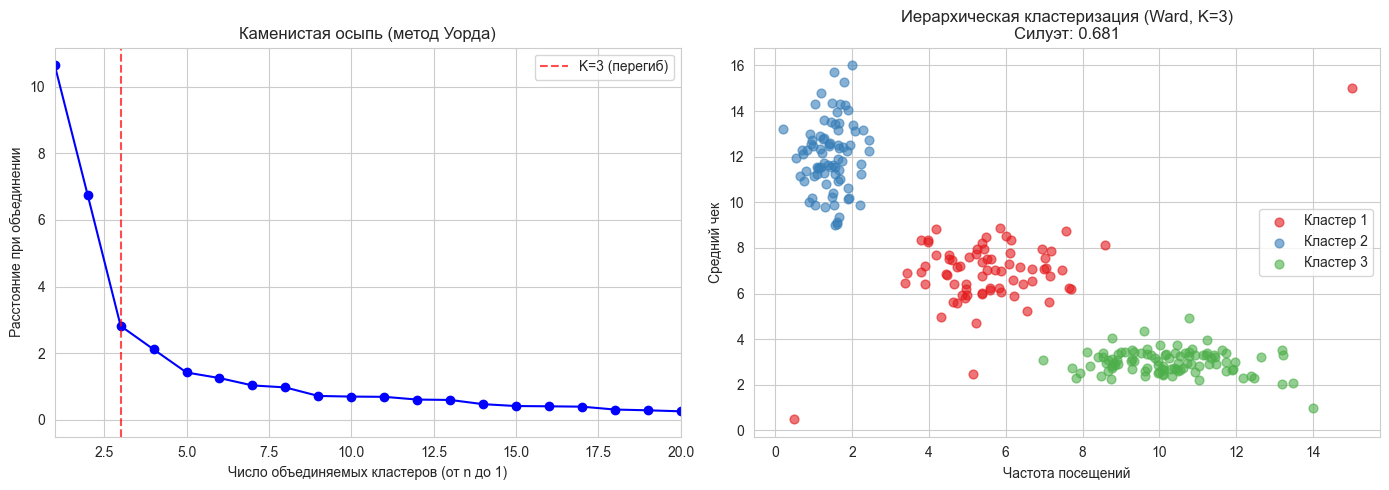

In [86]:
# Каменистая осыпь (scree plot) для метода Уорда
Z_ward = linkage(X_sample, method='ward')
# Расстояния при объединениях, от последнего к первому
merge_distances = Z_ward[:, 2][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(merge_distances) + 1), merge_distances, 'bo-', markersize=6)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (перегиб)')
axes[0].set_xlabel('Число объединяемых кластеров (от n до 1)')
axes[0].set_ylabel('Расстояние при объединении')
axes[0].set_title('Каменистая осыпь (метод Уорда)')
axes[0].set_xlim(1, 20)
axes[0].legend()

# Результат агломеративной кластеризации vs K-Means
hclust_ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_h = hclust_ward.fit_predict(X_scaled)

colors = ['#e41a1c', '#377eb8', '#4daf4a']
for k in range(3):
    mask = labels_h == k
    axes[1].scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.6, s=40, label=f'Кластер {k+1}')
sil_h = silhouette_score(X_scaled, labels_h)
axes[1].set_xlabel('Частота посещений')
axes[1].set_ylabel('Средний чек')
axes[1].set_title(f'Иерархическая кластеризация (Ward, K=3)\nСилуэт: {sil_h:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Задание: сравнение методов связи

Используя LLM для генерации кода:
1. Примените `AgglomerativeClustering` с `n_clusters=3` и методами `single`, `complete`, `average`, `ward` к полному датасету `X_scaled`.
2. Для каждого метода выведите силуэтный коэффициент и постройте scatter-plot.
3. Какой метод дал наилучший результат и почему? Какой метод объединил выбросы в основные кластеры, а какой выделил их отдельно?

In [87]:
# YOUR CODE HERE

### Ответ

Матрица `Z` из `linkage` содержит $n-1$ строк. Каждая строка — одно объединение: первые два столбца — индексы объединяемых кластеров, третий — расстояние. Берём третий столбец в обратном порядке и строим каменистую осыпь. Резкий скачок между объединением $k$-го и $(k+1)$-го кластеров означает, что «природным» является разбиение именно на $k$ кластеров.

**Методы связи:** одиночная связь склонна создавать «цепочки» и плохо разделяет несферические кластеры. Полная и средняя связь создают более компактные кластеры. Метод Уорда, минимизируя прирост дисперсии, обычно даёт результаты, наиболее близкие к K-Means, но без зависимости от инициализации.

**Недостаток иерархической кластеризации:** вычислительная сложность $O(n^2 \log n)$ — на датасетах с $n > 10\ 000$ работает медленно.

## DBSCAN

### Идея и основные определения

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) — кластеры это **плотные скопления** точек, разделённые разреженными областями.

**Определения:**
- **$\varepsilon$-окрестность** точки $x_0$: $\overline{B}(x_0, \varepsilon) = \{y \in X : d(x_0, y) \leq \varepsilon\}$
- **Корневая точка (core point):** $|\overline{B}(x_0, \varepsilon)| \geq m$ — точка имеет не менее $m$ соседей.
- **Граничная точка (border point):** не корневая, но в $\varepsilon$-окрестности какой-либо корневой точки.
- **Выброс (noise):** не корневая и не граничная.

**Алгоритм:**
1. Задать параметры $\varepsilon > 0$ и $m \in \mathbb{N}$.
2. Найти произвольную корневую точку $x$. Если таких нет — перейти к п. 7.
3. Всех соседей $x$ добавить в кластер $C_i$.
4. Для каждой корневой точки в $C_i$ рекурсивно добавить её соседей.
5. Повторять п. 4, пока состав $C_i$ не стабилизируется.
6. Удалить $C_i$, увеличить $i$, перейти к п. 2.
7. Все оставшиеся точки — выбросы.

**Замечание:** корневые точки и выбросы распределяются по кластерам **однозначно**. Граничные точки могут менять кластерную принадлежность при перезапуске (если находятся в окрестностях корневых точек разных кластеров).

In [29]:
# Визуализация типов точек в DBSCAN
np.random.seed(42)
X_demo, _ = make_blobs(n_samples=200, centers=2, cluster_std=0.5, random_state=42)
X_demo = np.vstack([X_demo, np.array([[5, 5], [-5, -4], [3, -3], [-3, 4]])])
X_demo_scaled = StandardScaler().fit_transform(X_demo)

dbscan_demo = DBSCAN(eps=0.4, min_samples=5)
labels_demo = dbscan_demo.fit_predict(X_demo_scaled)

core_mask = np.zeros(len(labels_demo), dtype=bool)
core_mask[dbscan_demo.core_sample_indices_] = True
noise_mask = labels_demo == -1
border_mask = ~core_mask & ~noise_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_demo_scaled[core_mask, 0], X_demo_scaled[core_mask, 1],
               c='steelblue', s=60, alpha=0.8, label=f'Корневые ({core_mask.sum()})')
axes[0].scatter(X_demo_scaled[border_mask, 0], X_demo_scaled[border_mask, 1],
               c='orange', s=60, alpha=0.8, label=f'Граничные ({border_mask.sum()})')
axes[0].scatter(X_demo_scaled[noise_mask, 0], X_demo_scaled[noise_mask, 1],
               c='red', marker='X', s=150, label=f'Выбросы ({noise_mask.sum()})')
demo_core_pt = X_demo_scaled[dbscan_demo.core_sample_indices_[10]]
circle = plt.Circle(demo_core_pt, 0.4, fill=False, color='navy',
                    linestyle='--', linewidth=2, label='ε-окрестность')
axes[0].add_patch(circle)
axes[0].set_xlim(-3, 3); axes[0].set_ylim(-3, 3)
axes[0].set_aspect('equal')
axes[0].set_title('Типы точек в DBSCAN (ε=0.4, m=5)')
axes[0].legend(fontsize=9)

for lbl in sorted(set(labels_demo)):
    mask_l = labels_demo == lbl
    if lbl == -1:
        axes[1].scatter(X_demo_scaled[mask_l, 0], X_demo_scaled[mask_l, 1],
                       c='red', marker='X', s=150, label='Выбросы')
    else:
        axes[1].scatter(X_demo_scaled[mask_l, 0], X_demo_scaled[mask_l, 1],
                       s=50, alpha=0.7, label=f'Кластер {lbl+1}')
axes[1].set_title('Результат DBSCAN')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Найдено кластеров: {len(set(labels_demo)) - (1 if -1 in labels_demo else 0)}")
print(f"Выбросов: {noise_mask.sum()}")

<IPython.core.display.Javascript object>

Найдено кластеров: 2
Выбросов: 3


### Выбор параметра ε: k-dist график

In [30]:
# Эвристика: график расстояния до min_samples-го ближайшего соседа
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_distances, 'b-', linewidth=1.5)
axes[0].axhline(y=0.5, color='red', linestyle='--', label='ε ≈ 0.5 (перегиб)')
axes[0].set_xlabel('Объекты (по убыванию расстояния)')
axes[0].set_ylabel(f'Расстояние до {min_samples}-го соседа')
axes[0].set_title('k-dist график для выбора ε')
axes[0].legend()

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
unique_db = set(labels_db)
n_clusters_db = len(unique_db) - (1 if -1 in unique_db else 0)
n_noise_db = np.sum(labels_db == -1)

for lbl in sorted(unique_db):
    mask_l = labels_db == lbl
    if lbl == -1:
        axes[1].scatter(X[mask_l, 0], X[mask_l, 1], c='red', marker='X',
                       s=150, zorder=5, label=f'Выбросы ({mask_l.sum()})')
    else:
        axes[1].scatter(X[mask_l, 0], X[mask_l, 1], s=40, alpha=0.7,
                       label=f'Кластер {lbl+1} ({mask_l.sum()})')

axes[1].set_xlabel('Частота посещений')
axes[1].set_ylabel('Средний чек')
axes[1].set_title(f'DBSCAN (ε=0.5, min_samples=5)\nКластеров: {n_clusters_db}, Выбросов: {n_noise_db}')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

### DBSCAN против K-Means: нелинейные кластеры

In [31]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

datasets_nl = [(X_moons, y_moons, 'Полумесяцы', {'eps': 0.2, 'min_samples': 5}),
               (X_circles, y_circles, 'Концентрические кольца', {'eps': 0.15, 'min_samples': 5})]

for row, (X_d, y_d, title, db_params) in enumerate(datasets_nl):
    X_ds = StandardScaler().fit_transform(X_d)
    lbl_km = KMeans(n_clusters=2, random_state=42).fit_predict(X_ds)
    lbl_db = DBSCAN(**db_params).fit_predict(X_ds)
    noise_d = lbl_db == -1

    axes[row, 0].scatter(X_d[:, 0], X_d[:, 1], c=y_d, cmap='RdBu', s=30, alpha=0.8)
    axes[row, 0].set_title(f'{title}: истинные кластеры')

    axes[row, 1].scatter(X_d[:, 0], X_d[:, 1], c=lbl_km, cmap='RdBu', s=30, alpha=0.8)
    sil_km = silhouette_score(X_ds, lbl_km)
    axes[row, 1].set_title(f'K-Means (силуэт={sil_km:.3f})')

    axes[row, 2].scatter(X_d[~noise_d, 0], X_d[~noise_d, 1],
                        c=lbl_db[~noise_d], cmap='RdBu', s=30, alpha=0.8)
    axes[row, 2].scatter(X_d[noise_d, 0], X_d[noise_d, 1],
                        c='gray', marker='x', s=80, label='Шум')
    n_cl = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
    if n_cl > 1:
        sil_db = silhouette_score(X_ds[~noise_d], lbl_db[~noise_d])
        axes[row, 2].set_title(f'DBSCAN (силуэт={sil_db:.3f}, {n_cl} кл.)')
    else:
        axes[row, 2].set_title(f'DBSCAN ({n_cl} кластер)')

plt.suptitle('K-Means vs DBSCAN на нелинейных данных', fontsize=14)
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobil

**Вопросы:**
- Что произойдёт с DBSCAN при слишком малом / слишком большом $\varepsilon$?
- Почему граничные точки могут менять кластерную принадлежность при перезапуске, а корневые — нет?
- В каких ситуациях DBSCAN объединит два «очевидно разных» кластера в один?

### Ответ

**Влияние $\varepsilon$:** при слишком малом $\varepsilon$ почти ни одна точка не наберёт $m$ соседей — все станут выбросами. При слишком большом $\varepsilon$ весь датасет окажется одним кластером.

**Нестабильность граничных точек:** корневые точки определяются однозначно — их статус зависит только от числа соседей, а не от порядка обхода. Граничная точка попадает в $\varepsilon$-окрестности корневых точек **из разных кластеров** — и её «судьба» определяется тем, какая корневая точка обработана раньше.

**Проблема перемычек:** если два плотных кластера соединены цепочкой плотно расположенных промежуточных точек, DBSCAN объединит их в один кластер. При большой размерности данных это особенно трудно обнаружить, так как визуализировать данные не представляется возможным.

**Важно:** так как DBSCAN использует расстояния, признаки рекомендуется стандартизировать или нормировать перед применением алгоритма.

### Задание: влияние параметров DBSCAN

Используя LLM для генерации кода:
1. Примените DBSCAN к датасету `make_moons` с `eps` ∈ {0.05, 0.2, 0.5, 1.0} при `min_samples=5`.
2. Для каждого значения выведите число кластеров, число выбросов, силуэт (если кластеров ≥ 2).
3. Постройте 4 графика. Сделайте вывод о чувствительности DBSCAN к параметру $\varepsilon$.

In [32]:
# YOUR CODE HERE

## Поиск аномалий с помощью кластеризации

Кластеризация — инструмент **обнаружения аномалий (anomaly detection)**. Объекты, не вписывающиеся ни в один кластер, могут быть аномалиями, ошибками сбора данных или редкими значимыми событиями.

In [33]:
np.random.seed(42)
normal_data = np.vstack([
    np.random.randn(150, 2) * [0.4, 1.2] + [1.5, 12],
    np.random.randn(150, 2) * [1.2, 0.4] + [10, 3],
    np.random.randn(100, 2) * [0.8, 0.8] + [5.5, 7]
])
anomalies = np.array([[15, 15], [0.2, 0.2], [13, 1], [1.5, 17],
                       [8, 13], [12, 10], [3, 0.5], [0.8, 14]])

X_all = np.vstack([normal_data, anomalies])
X_all_scaled = StandardScaler().fit_transform(X_all)
true_labels = np.array([0] * len(normal_data) + [1] * len(anomalies))

# --- Метод 1: DBSCAN ---
dbscan_anom = DBSCAN(eps=0.45, min_samples=8)
labels_db_anom = dbscan_anom.fit_predict(X_all_scaled)
detected_dbscan = (labels_db_anom == -1).astype(int)

# --- Метод 2: K-Means, расстояние до центроида ---
kmeans_anom = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_anom.fit(X_all_scaled)
dists_to_centers = np.min(cdist(X_all_scaled, kmeans_anom.cluster_centers_), axis=1)
threshold_km = np.percentile(dists_to_centers, 95)
detected_kmeans = (dists_to_centers > threshold_km).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_all[true_labels == 0, 0], X_all[true_labels == 0, 1],
               c='steelblue', s=30, alpha=0.6, label='Норма')
axes[0].scatter(X_all[true_labels == 1, 0], X_all[true_labels == 1, 1],
               c='red', marker='*', s=200, zorder=5, label=f'Аномалии ({len(anomalies)})')
axes[0].set_title('Истинные аномалии')
axes[0].legend(); axes[0].set_xlabel('Частота'); axes[0].set_ylabel('Средний чек')

axes[1].scatter(X_all[detected_dbscan == 0, 0], X_all[detected_dbscan == 0, 1],
               c='steelblue', s=30, alpha=0.6, label='Норма')
axes[1].scatter(X_all[detected_dbscan == 1, 0], X_all[detected_dbscan == 1, 1],
               c='red', marker='*', s=200, zorder=5, label=f'Выбросы ({detected_dbscan.sum()})')
p_db = np.sum(detected_dbscan & true_labels) / max(detected_dbscan.sum(), 1)
r_db = np.sum(detected_dbscan & true_labels) / len(anomalies)
axes[1].set_title(f'DBSCAN\nТочность={p_db:.2f}, Полнота={r_db:.2f}')
axes[1].legend(); axes[1].set_xlabel('Частота')

sc = axes[2].scatter(X_all[:, 0], X_all[:, 1], c=dists_to_centers, cmap='YlOrRd', s=40, alpha=0.8)
axes[2].scatter(X_all[detected_kmeans == 1, 0], X_all[detected_kmeans == 1, 1],
               c='red', marker='*', s=200, zorder=5, label=f'Флаговые ({detected_kmeans.sum()})')
plt.colorbar(sc, ax=axes[2], label='Расстояние до центроида')
p_km = np.sum(detected_kmeans & true_labels) / max(detected_kmeans.sum(), 1)
r_km = np.sum(detected_kmeans & true_labels) / len(anomalies)
axes[2].set_title(f'K-Means (порог 95%\nТочность={p_km:.2f}, Полнота={r_km:.2f}')
axes[2].legend(fontsize=9); axes[2].set_xlabel('Частота')

plt.suptitle('Обнаружение аномалий', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n{'Метод':<15} {'Найдено':<10} {'Точность':<12} {'Полнота'}")
print(f"{'DBSCAN':<15} {detected_dbscan.sum():<10} {p_db:<12.2f} {r_db:.2f}")
print(f"{'K-Means 95%':<15} {detected_kmeans.sum():<10} {p_km:<12.2f} {r_km:.2f}")

<IPython.core.display.Javascript object>


Метод           Найдено    Точность     Полнота
DBSCAN          5          1.00         0.62
K-Means 95%     21         0.33         0.88


### Комментарий

**DBSCAN** обнаруживает аномалии естественным образом — точки, не являющиеся ни корневыми, ни граничными, по определению выбросы. Метод не требует дополнительного порога.

**K-Means** использует расстояние до ближайшего центроида как «оценку аномальности». Нужно задать порог — он зависит от задачи и допустимого числа ложных тревог. Недостаток: если аномалии образуют плотный кластер, K-Means создаст для них отдельный кластер вместо флагирования.

На практике для обнаружения аномалий применяют специализированные методы: **Isolation Forest**, **Local Outlier Factor**, **One-class SVM**. Кластеризация полезна на этапе разведочного анализа.

### Задание: анализ порогов

Используя LLM для генерации кода:
1. Постройте гистограмму `dists_to_centers` с вертикальными линиями для порогов 90%, 95%, 99%-го перцентиля.
2. Для каждого порога выведите: количество флаговых точек, точность и полноту.
3. Постройте кривую «точность–полнота» при изменении порога от 50-го до 100-го перцентиля.
4. Обсудите: как выбрать порог на практике?

In [34]:
# YOUR CODE HERE

## Кейс: систематическое сравнение алгоритмов

In [35]:
np.random.seed(42)

datasets = {
    'Шаровые сгустки (равные)': make_blobs(n_samples=300, centers=3, cluster_std=0.7, random_state=42),
    'Шаровые сгустки (разные)': make_blobs(n_samples=300,
                                             centers=[[-5, -5], [0, 0], [5, 5]],
                                             cluster_std=[0.5, 1.5, 0.8], random_state=42),
    'Полумесяцы': make_moons(n_samples=300, noise=0.1, random_state=42),
    'Концентрические кольца': make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
}

algorithms = {
    'K-Means': lambda X, k: KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X),
    'Иерарх. (Ward)': lambda X, k: AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X),
    'DBSCAN': lambda X, _: DBSCAN(eps=0.35, min_samples=7).fit_predict(X)
}
k_vals = {'Шаровые сгустки (равные)': 3, 'Шаровые сгустки (разные)': 3,
          'Полумесяцы': 2, 'Концентрические кольца': 2}

fig, axes = plt.subplots(len(datasets), len(algorithms) + 1, figsize=(20, 16))

for row, (ds_name, (X_ds, y_true)) in enumerate(datasets.items()):
    X_ds_s = StandardScaler().fit_transform(X_ds)
    k = k_vals[ds_name]

    axes[row, 0].scatter(X_ds[:, 0], X_ds[:, 1], c=y_true, cmap='Set1', s=20, alpha=0.8)
    axes[row, 0].set_title('Истина' if row == 0 else '', fontsize=10)
    axes[row, 0].set_ylabel(ds_name, fontsize=9)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    for col, (alg_name, alg_func) in enumerate(algorithms.items()):
        lbl = alg_func(X_ds_s, k)
        noise_m = lbl == -1
        if noise_m.sum() > 0:
            axes[row, col+1].scatter(X_ds[noise_m, 0], X_ds[noise_m, 1],
                                    c='gray', marker='x', s=40, alpha=0.5)
        axes[row, col+1].scatter(X_ds[~noise_m, 0], X_ds[~noise_m, 1],
                                c=lbl[~noise_m], cmap='Set1', s=20, alpha=0.8)
        valid = lbl[~noise_m]
        sil_txt = f'S={silhouette_score(X_ds_s[~noise_m], valid):.2f}' if len(set(valid)) > 1 else 'S=N/A'
        n_ns = noise_m.sum()
        title_t = f'{alg_name}\n{sil_txt}' if row == 0 else sil_txt
        if n_ns > 0: title_t += f', шум:{n_ns}'
        axes[row, col+1].set_title(title_t, fontsize=9)
        axes[row, col+1].set_xticks([]); axes[row, col+1].set_yticks([])

plt.suptitle('Сравнение алгоритмов кластеризации на разных типах данных', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobil

### Кейс на реальных данных: ирисы Фишера

In [36]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_iris_s = StandardScaler().fit_transform(X_iris)

pca = PCA(n_components=2, random_state=42)
X_iris_2d = pca.fit_transform(X_iris_s)

algs_iris = {
    'K-Means': KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_iris_s),
    'Иерархическая (Ward)': AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_iris_s),
    'DBSCAN': DBSCAN(eps=0.8, min_samples=5).fit_predict(X_iris_s)
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_iris, cmap='Set1', s=40, alpha=0.8)
axes[0].set_title('Истинные классы')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

for ax, (name, lbl) in zip(axes[1:], algs_iris.items()):
    noise = lbl == -1
    ax.scatter(X_iris_2d[~noise, 0], X_iris_2d[~noise, 1], c=lbl[~noise], cmap='Set1', s=40, alpha=0.8)
    if noise.sum() > 0:
        ax.scatter(X_iris_2d[noise, 0], X_iris_2d[noise, 1], c='gray', marker='x', s=80)
    valid = lbl[~noise]
    n_cl = len(set(valid))
    sil = silhouette_score(X_iris_s[~noise], valid) if n_cl > 1 else float('nan')
    ax.set_title(f'{name}\nСилуэт={sil:.3f}' if not np.isnan(sil) else f'{name}\n({n_cl} кл.)')
    ax.set_xlabel('PC1')

plt.suptitle('Кластеризация ирисов Фишера (PCA 2D)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'Алгоритм':<25} {'Кластеров':<12} {'Выбросов':<12} {'Силуэт'}")
for name, lbl in algs_iris.items():
    noise = lbl == -1
    valid = lbl[~noise]
    n_cl = len(set(valid))
    sil = silhouette_score(X_iris_s[~noise], valid) if n_cl > 1 else float('nan')
    print(f"{name:<25} {n_cl:<12} {noise.sum():<12} {sil:.4f}")

<IPython.core.display.Javascript object>


Алгоритм                  Кластеров    Выбросов     Силуэт
K-Means                   3            0            0.4599
Иерархическая (Ward)      3            0            0.4467
DBSCAN                    2            4            0.5979


/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobile Documents/com~apple~CloudDocs/_dev/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/romanov/Library/Mobil

## Итоговое сравнение алгоритмов

| Характеристика | K-Means | Иерархическая (Ward) | DBSCAN |
|---|---|---|---|
| **Задаётся K?** | Да | Нет (выбор по дендрограмме) | Нет |
| **Форма кластеров** | Шаровая | Шаровая | Произвольная |
| **Выбросы** | Включает в кластеры | Включает в кластеры | Явно помечает |
| **Детерминизм** | Зависит от инициализации | Да | Да (кроме граничных точек) |
| **Масштабируемость** | $O(nKt)$ — отличная | $O(n^2 \log n)$ — слабая | $O(n \log n)$ — хорошая |
| **Разные размеры кластеров** | Плохо | Удовлетворительно | Хорошо |
| **Интерпретируемость** | Центроиды | Дендрограмма | Типы точек |
| **Когда применять** | Большие данные, шаровые кластеры | Малые данные, нужна иерархия | Нелинейные формы, важны выбросы |

## Финальное задание: полный пайплайн кластеризации

Используя LLM для генерации кода, реализуйте полный пайплайн на датасете `load_wine()` из sklearn.

**Шаг 1. Загрузка и EDA.** Выведите размерность, описательную статистику (`describe()`), проверьте пропуски.

**Шаг 2. Предобработка.** Стандартизируйте признаки. Объясните необходимость этого шага.

**Шаг 3. Выбор K.** Постройте метод локтя и силуэтный анализ для $K$ от 2 до 8. Выберите оптимальное $K$.

**Шаг 4. Три алгоритма.** Примените K-Means, иерархическую кластеризацию (Ward) и DBSCAN (подберите параметры). Выведите силуэт для каждого.

**Шаг 5. Визуализация.** Используйте `PCA(n_components=2)` и постройте scatter-plot с раскраской по кластерам.

**Шаг 6. Интерпретация.** Для лучшего алгоритма выведите средние значения признаков по каждому кластеру. Предложите содержательную интерпретацию: что объединяет вина в каждом кластере?

**Шаг 7. Аномалии.** Найдите 5 наиболее «нетипичных» вин по расстоянию до ближайшего центроида K-Means.

In [37]:
# Шаги 1–2: Загрузка и предобработка
# YOUR CODE HERE

In [38]:
# Шаг 3: Выбор числа кластеров
# YOUR CODE HERE

In [39]:
# Шаги 4–5: Кластеризация и визуализация
# YOUR CODE HERE

In [40]:
# Шаги 6–7: Интерпретация и аномалии
# YOUR CODE HERE

## Подводим итоги

В этом блокноте мы разобрали три ключевых алгоритма кластеризации и важные сопутствующие концепции.

**Что важно помнить:**

**Кластеризация — задача без учителя.** Нет единственно правильного ответа; результат зависит от алгоритма, метрики, предобработки и параметров. Всегда сравнивайте несколько методов.

**Стандартизация критична.** Признаки разного масштаба делают евклидово расстояние бессмысленным — один признак «заглушает» остальные.

**K-Means** быстр и интерпретируем (центроиды легко объяснить бизнесу), но предполагает шаровые кластеры равного размера. Чувствителен к выбросам. K-Means++ решает проблему плохой инициализации.

**Иерархическая кластеризация** не требует задавать $K$ заранее, даёт красивую дендрограмму. Медленно работает на больших данных — $O(n^2 \log n)$.

**DBSCAN** находит кластеры произвольной формы и явно выделяет выбросы. Требует тщательного подбора $\varepsilon$ и `min_samples`. Плохо работает при кластерах сильно разной плотности.

**Метрики качества:** инерция + метод локтя — для выбора $K$; силуэтный коэффициент — универсальная внешняя метрика.

**Выбор алгоритма — это искусство.** Начинайте с визуализации (PCA или t-SNE), пробуйте несколько методов, интерпретируйте результаты содержательно, а не только по числам.